# Beta-Binomial



## Exercise: Beta-Binomial and Stan MCMC

주어진 데이터: 동전 던지기 $N=51$, 앞면 횟수 $y=11$, 모수는 $\theta=P(\text{head})$.

$$
    Y \sim Binomial(N, \theta)
$$

Binomial Probability Mass Function:
$$
    Pr[Y = y| N, \theta] = \binom{N}{y} \theta^y (1-\theta)^{N-y}
$$

## Three methods
1. $H_0: \theta=0.5$ 에 대해 NH(빈도주의) 가설검정 수행
2. 사전분포 $\theta\sim\mathrm{Beta}(3,3)$일 때 사후분포와 $P(\theta>0.55)$
3. Stan/cmdstanpy로 MCMC 사후추정

In [1]:
import numpy as np
from scipy.stats import beta, binomtest

# Given data
N = 51   # 동전 갯수
y = 15   # 실험에서 얻은 앞면의 수


### 1. H0 영가설 검정 (NH Test, Exact Binomial)

관측값은 $Y=y=11$, 표본수는 $N=51$, 검정할 영가설은 $H_0:\theta=0.5$ 입니다.

검정의 핵심 아이디어:

1. **영가설 하에서 분포를 고정**
   $$
   Y\mid H_0 \sim \mathrm{Binomial}(N=51,\,\theta=0.5)
   $$

2. **관측값의 극단성 계산**
   - 단측(왼쪽) 검정 $H_1:\theta<0.5$:
     $$
     p\text{-value}=P_{H_0}(Y\le y_{obs})=\sum_{k=0}^{11}\binom{51}{k}(0.5)^k(0.5)^{51-k}
     $$
   - 양측 검정 $H_1:\theta\ne 0.5$:
     SciPy `binomtest(..., alternative="two-sided")`는
     **관측값과 같거나 더 작은 확률질량(PMF)을 갖는 값들**을 양쪽 꼬리에서 모두 더해 p-value를 만듭니다.
     즉
     $$
     p\text{-value}=\sum_{k:~P_{H_0}(Y=k)\le P_{H_0}(Y=y_{obs})} P_{H_0}(Y=k)
     $$
     (단순히 $2\times\min\{P(Y\le y), P(Y\ge y)\}$ 와는 일반적으로 다를 수 있습니다.)

3. **의사결정**
   유의수준 $\alpha=0.05$에서 p-value < $\alpha$ 이면 $H_0$ 기각.

현재 데이터에서는 양측 p-value가 매우 작아 $H_0:\theta=0.5$를 기각합니다.

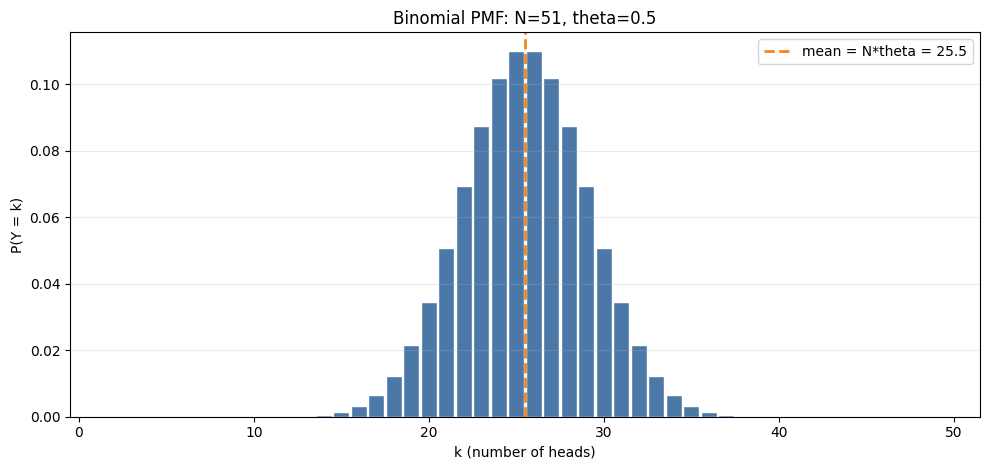

In [2]:
import matplotlib.pyplot as plt
from scipy.stats import binom

# Binomial PMF for N=51, theta=0.5
N_plot = 51
theta_plot = 0.5
k_plot = np.arange(N_plot + 1)
pmf_plot = binom.pmf(k_plot, N_plot, theta_plot)

plt.figure(figsize=(10, 4.8))
plt.bar(k_plot, pmf_plot, color="#4C78A8", edgecolor="white", width=0.9)
plt.axvline(N_plot * theta_plot, color="#F58518", linestyle="--", linewidth=2, label=f"mean = N*theta = {N_plot*theta_plot:.1f}")
plt.title("Binomial PMF: N=51, theta=0.5")
plt.xlabel("k (number of heads)")
plt.ylabel("P(Y = k)")
plt.xlim(-0.5, N_plot + 0.5)
plt.grid(axis="y", alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

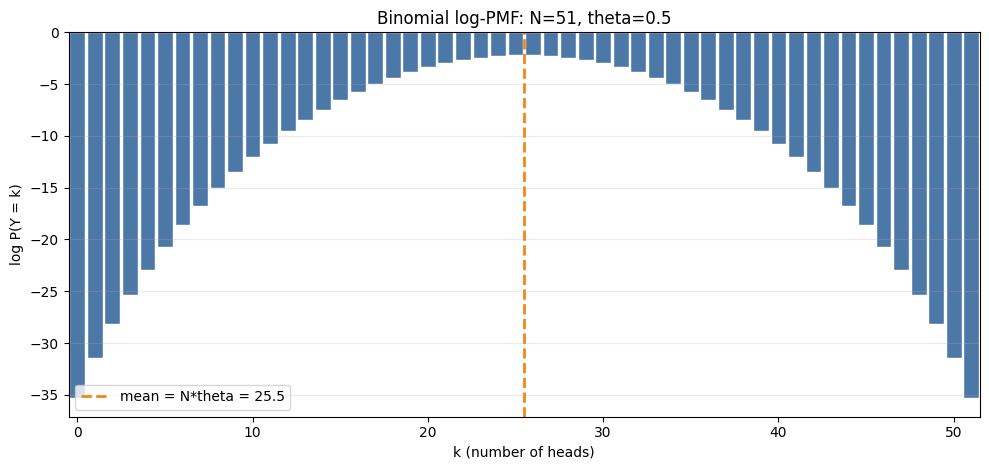

In [3]:
import matplotlib.pyplot as plt
from scipy.stats import binom

# Binomial PMF for N=51, theta=0.5
N_plot = 51
theta_plot = 0.5
k_plot = np.arange(N_plot + 1)
pmf_plot = np.log(binom.pmf(k_plot, N_plot, theta_plot))

plt.figure(figsize=(10, 4.8))
plt.bar(k_plot, pmf_plot, color="#4C78A8", edgecolor="white", width=0.9)
plt.axvline(N_plot * theta_plot, color="#F58518", linestyle="--", linewidth=2, 
label=f"mean = N*theta = {N_plot*theta_plot:.1f}")
plt.title("Binomial log-PMF: N=51, theta=0.5")
plt.xlabel("k (number of heads)")
plt.ylabel("log P(Y = k)")
plt.xlim(-0.5, N_plot + 0.5)
plt.grid(axis="y", alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

In [4]:
# 1) NH test for H0: theta = 0.5 (exact binomial test)
h0_theta = 0.5
alpha = 0.05

test_two_sided = binomtest(k=y, n=N, p=h0_theta, alternative="two-sided")
test_less = binomtest(k=y, n=N, p=h0_theta, alternative="less")

print(f"[1] NH test for H0: theta={h0_theta}")
print(f"Observed y={y} out of N={N}")
print(f"Two-sided exact binomial p-value = {test_two_sided.pvalue:.10f}")
print(f"One-sided (theta < 0.5) p-value  = {test_less.pvalue:.10f}")
print(f"Decision at alpha={alpha}: {'Reject H0' if test_two_sided.pvalue < alpha else 'Fail to reject H0'}")

[1] NH test for H0: theta=0.5
Observed y=15 out of N=51
Two-sided exact binomial p-value = 0.0046013097
One-sided (theta < 0.5) p-value  = 0.0023006549
Decision at alpha=0.05: Reject H0


In [5]:
from scipy.stats import binom

# --- Manual reconstruction of scipy.stats.binomtest p-values ---

# 1) One-sided (less): P(Y <= y_obs | H0)
p_less_manual = binom.cdf(y, N, h0_theta)

# 2) Two-sided (SciPy exact definition):
#    Sum probabilities of all outcomes whose PMF is <= PMF at observed y.
k = np.arange(N + 1)
pmf_all = binom.pmf(k, N, h0_theta)
pmf_obs = binom.pmf(y, N, h0_theta)
p_two_manual = pmf_all[pmf_all <= pmf_obs + 1e-15].sum()

print("[Manual check of binomtest internals]")
print(f"Observed PMF P(Y={y}|H0) = {pmf_obs:.12e}")
print(f"One-sided less p-value   (manual) = {p_less_manual:.10e}")
print(f"One-sided less p-value (binomtest)= {test_less.pvalue:.10e}")
print(f"Two-sided exact p-value  (manual) = {p_two_manual:.10e}")
print(f"Two-sided exact p-value(binomtst)= {test_two_sided.pvalue:.10e}")
print(f"Absolute diff (two-sided)         = {abs(p_two_manual - test_two_sided.pvalue):.3e}")

[Manual check of binomtest internals]
Observed PMF P(Y=15|H0) = 1.416056263990e-03
One-sided less p-value   (manual) = 2.3006548559e-03
One-sided less p-value (binomtest)= 2.3006548559e-03
Two-sided exact p-value  (manual) = 4.6013097118e-03
Two-sided exact p-value(binomtst)= 4.6013097118e-03
Absolute diff (two-sided)         = 3.469e-18


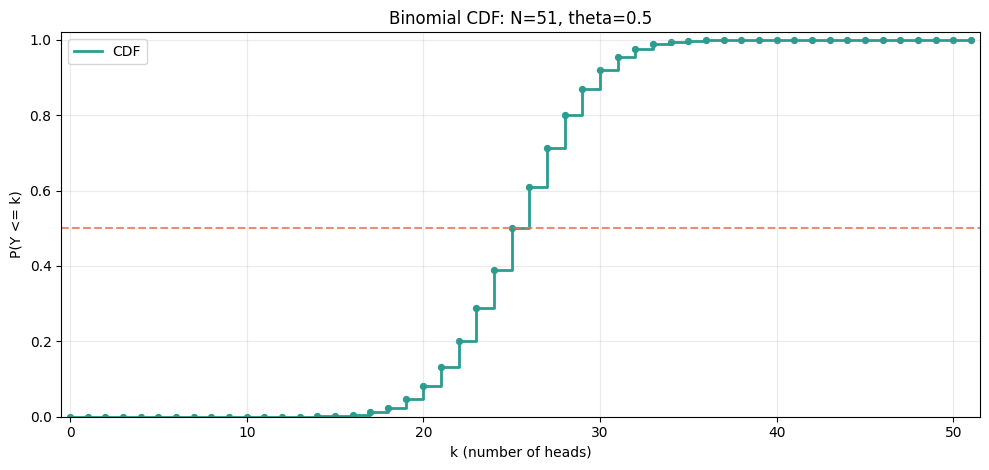

In [6]:
import matplotlib.pyplot as plt
from scipy.stats import binom

# Binomial CDF for N=51, theta=0.5
N_cdf = 51
theta_cdf = 0.5
k_cdf = np.arange(N_cdf + 1)
cdf_vals = binom.cdf(k_cdf, N_cdf, theta_cdf)

plt.figure(figsize=(10, 4.8))
plt.step(k_cdf, cdf_vals, where="post", color="#2A9D8F", linewidth=2, label="CDF")
plt.scatter(k_cdf, cdf_vals, color="#2A9D8F", s=18)
plt.axhline(0.5, color="#E76F51", linestyle="--", linewidth=1.5, alpha=0.8)
plt.title("Binomial CDF: N=51, theta=0.5")
plt.xlabel("k (number of heads)")
plt.ylabel("P(Y <= k)")
plt.xlim(-0.5, N_cdf + 0.5)
plt.ylim(0, 1.02)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

### 2. Conjugate Prior Beta

### Conjugate Posterior (Symbolic Form)

사전분포(prior)와 가능도/우도(likelihood)를 다음과 같이 두면

\begin{align}
    Y\mid\theta & \sim \mathrm{Binomial}(n,\theta), \\
    Y& =y \quad\quad\mathrm{observation}\\
    \theta & \sim \mathrm{Beta}(a_0,b_0), \\
\end{align}

베타분포-이항분포 공액성(conjugacy)에 의해 사후분포는

$$
\theta\mid y \sim \mathrm{Beta}(a_0+y,\; b_0+n-y)
$$

즉, 성공 횟수 $y$는 첫 번째 모수에 더해지고, 실패 횟수 $n-y$는 두 번째 모수에 더해집니다.

In [7]:
# 2) Beta(3,3) prior -> posterior Beta(3+y, 3+N-y)
a0, b0 = 3, 3
a_post = a0 + y
b_post = b0 + (N - y)

p_theta_gt_055 = beta.sf(0.55, a_post, b_post)  # sf = 1 - cdf
post_mean = a_post / (a_post + b_post)

print("\n[2] Posterior with Beta(3,3) prior")
print(f"Posterior: Beta({a_post}, {b_post})")
print(f"Posterior mean E[theta|y] = {post_mean:.6f}")
print(f"P(theta > 0.55 | y) = {p_theta_gt_055:.10f}")
print(f"P(theta < 0.45 | y) = {1 - p_theta_gt_055:.10f}")



[2] Posterior with Beta(3,3) prior
Posterior: Beta(18, 39)
Posterior mean E[theta|y] = 0.315789
P(theta > 0.55 | y) = 0.0001696214
P(theta < 0.45 | y) = 0.9998303786


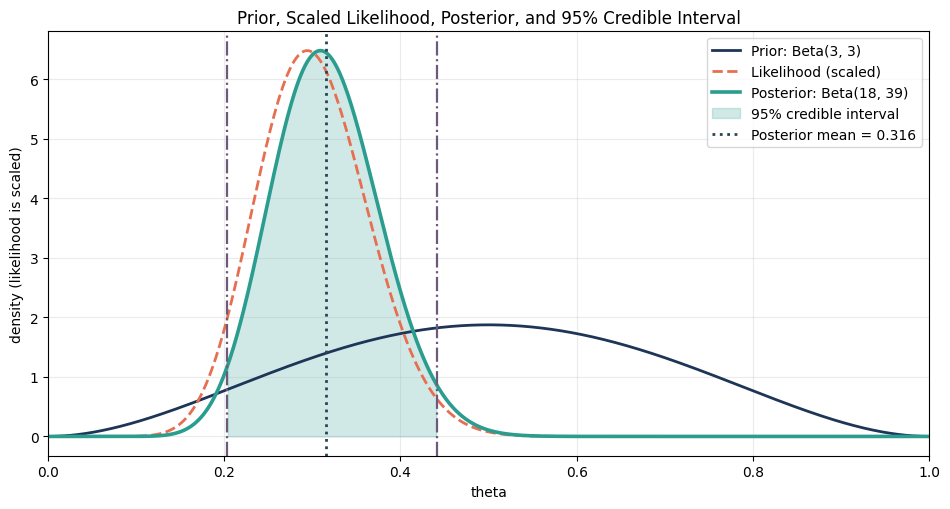

95% credible interval: [0.2029, 0.4410]


In [8]:
import matplotlib.pyplot as plt

# Grid on theta space
theta_grid = np.linspace(1e-4, 1 - 1e-4, 800)

# Prior and posterior densities
prior_pdf = beta.pdf(theta_grid, a0, b0)
posterior_pdf = beta.pdf(theta_grid, a_post, b_post)

# Likelihood shape L(theta|y) ∝ theta^y (1-theta)^(N-y)
likelihood_raw = (theta_grid ** y) * ((1 - theta_grid) ** (N - y))
likelihood_scaled = likelihood_raw / likelihood_raw.max()
# Rescale to posterior peak so all curves are visible on one density axis
likelihood_scaled_to_density = likelihood_scaled * posterior_pdf.max()

# 95% credible interval from posterior
ci_low, ci_high = beta.ppf([0.025, 0.975], a_post, b_post)

plt.figure(figsize=(9.6, 5.2))

# Curves
plt.plot(theta_grid, prior_pdf, color="#1D3557", linewidth=2.0, label=f"Prior: Beta({a0}, {b0})")
plt.plot(theta_grid, likelihood_scaled_to_density, color="#E76F51", linestyle="--", linewidth=2.0, label="Likelihood (scaled)")
plt.plot(theta_grid, posterior_pdf, color="#2A9D8F", linewidth=2.6, label=f"Posterior: Beta({a_post}, {b_post})")

# Shade 95% credible interval under posterior curve
mask = (theta_grid >= ci_low) & (theta_grid <= ci_high)
plt.fill_between(theta_grid[mask], 0, posterior_pdf[mask], color="#2A9D8F", alpha=0.22, label="95% credible interval")

# Vertical markers
plt.axvline(post_mean, color="#264653", linestyle=":", linewidth=2, label=f"Posterior mean = {post_mean:.3f}")
plt.axvline(ci_low, color="#6D597A", linestyle="-.", linewidth=1.6)
plt.axvline(ci_high, color="#6D597A", linestyle="-.", linewidth=1.6)

plt.title("Prior, Scaled Likelihood, Posterior, and 95% Credible Interval")
plt.xlabel("theta")
plt.ylabel("density (likelihood is scaled)")
plt.xlim(0, 1)
plt.grid(alpha=0.25)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

print(f"95% credible interval: [{ci_low:.4f}, {ci_high:.4f}]")

#### Beta distribution with (a,b)
$$
    p(\theta|a, b) = \frac{\theta^a (1-\theta)^b}{B(a,b)}
$$

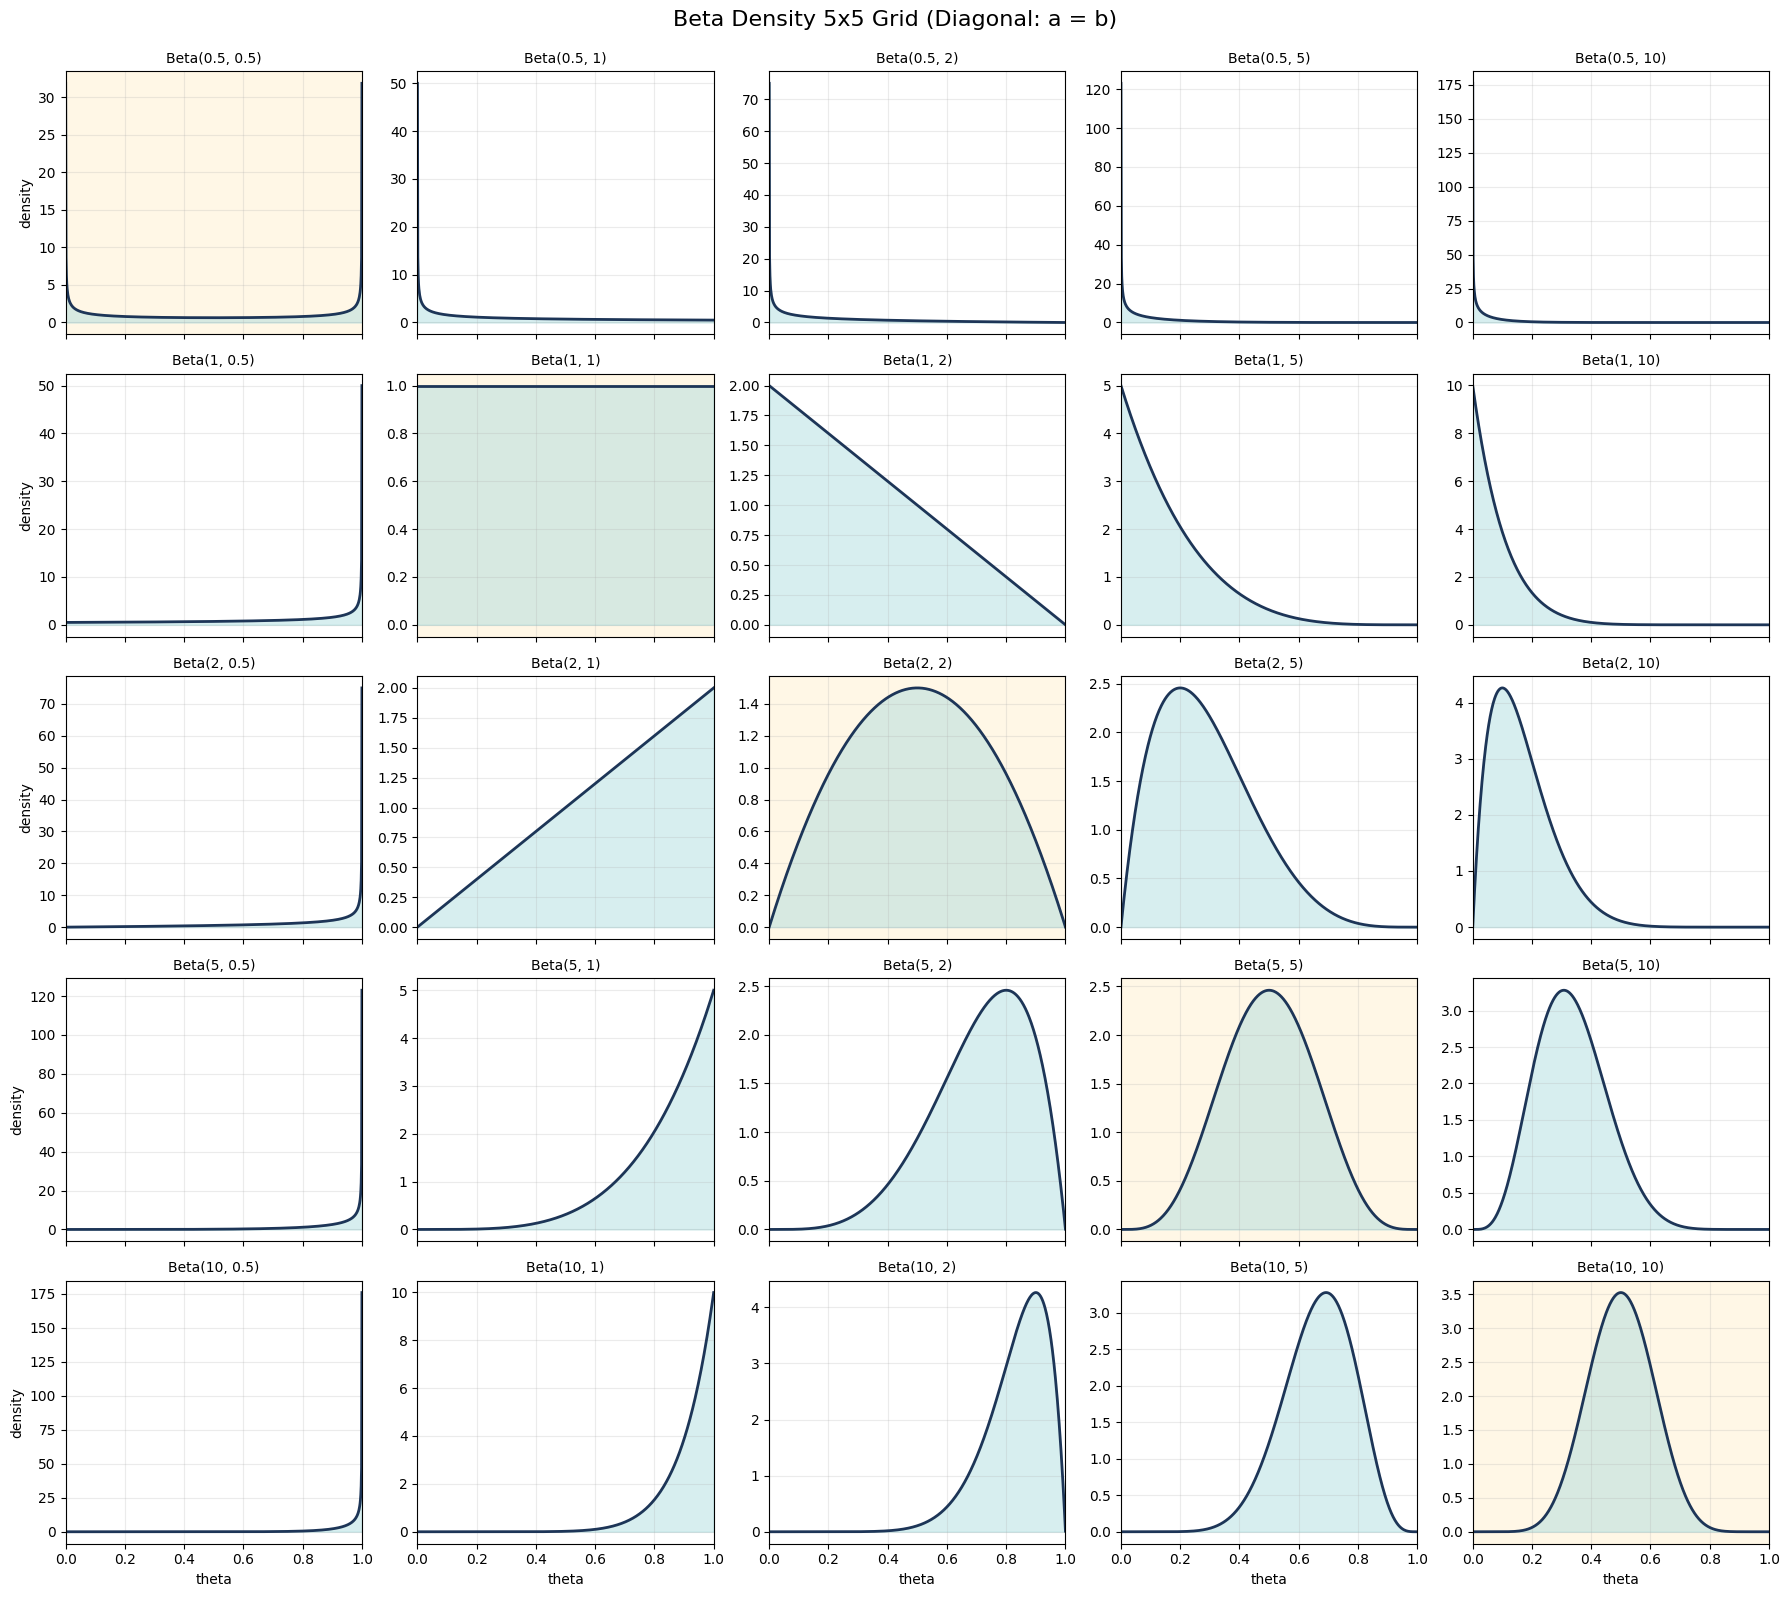

In [9]:
import matplotlib.pyplot as plt

# 5x5 grid of Beta(a, b) density plots
# Rows correspond to a, columns correspond to b.
# Therefore, diagonal panels satisfy a = b.
ab_values = [0.5, 1, 2, 5, 10]
theta = np.linspace(1e-4, 1 - 1e-4, 800)

fig, axes = plt.subplots(5, 5, figsize=(18, 16), sharex=True, sharey=False)

for i, a in enumerate(ab_values):
    for j, b in enumerate(ab_values):
        ax = axes[i, j]
        dens = beta.pdf(theta, a, b)
        ax.plot(theta, dens, color="#1D3557", linewidth=2)
        ax.fill_between(theta, 0, dens, color="#A8DADC", alpha=0.45)
        ax.set_title(f"Beta({a}, {b})", fontsize=10)
        ax.set_xlim(0, 1)
        ax.grid(alpha=0.25)

        # Highlight diagonal where a = b
        if i == j:
            ax.set_facecolor("#FFF7E6")

for ax in axes[-1, :]:
    ax.set_xlabel("theta")
for ax in axes[:, 0]:
    ax.set_ylabel("density")

fig.suptitle("Beta Density 5x5 Grid (Diagonal: a = b)", fontsize=16, y=0.995)
plt.tight_layout()
plt.show()

#### Beta with mode and concentration parameterization

For a Beta distribution $ \theta \sim \mathrm{Beta}(a,b) $

- mode $ \omega$  for $a,b>1$:  
  $$
  \omega=\frac{a-1}{a+b-2}  
  $$
- concentration $\kappa$ defined as  
  $$
  \kappa=a+b
  $$

- a and b w.r.t $\omega$ and $\kappa$:
$$
a=\omega(\kappa-2)+1 \\
b=(1-\omega)(\kappa-2)+1
$$



Mode (omega) = 0.1
Concentration (kappa) = 13
Corresponding Beta parameters: a = 2.10, b = 10.90


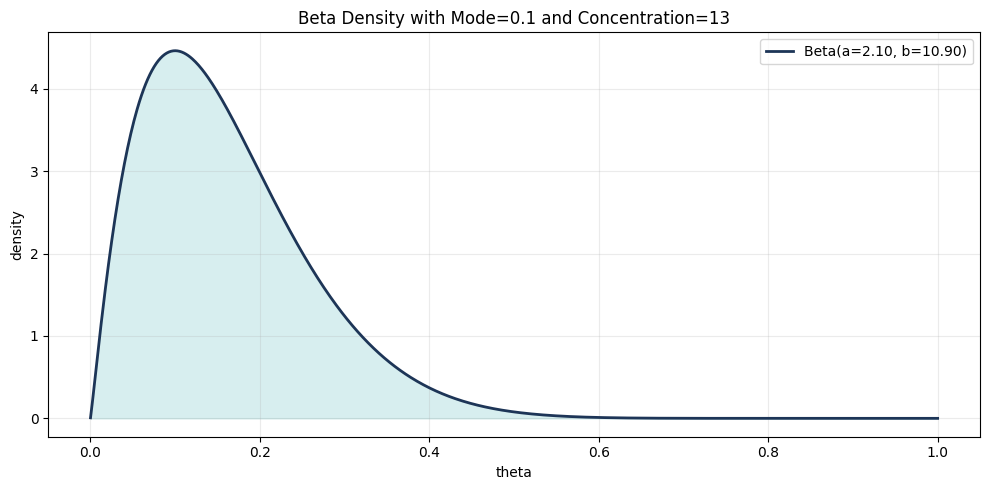

In [10]:
omega = 0.1
kappa = 13
a = omega * (kappa - 2) + 1
b = (1 - omega) * (kappa - 2) + 1
print(f"Mode (omega) = {omega}")
print(f"Concentration (kappa) = {kappa}")
print(f"Corresponding Beta parameters: a = {a:.2f}, b = {b:.2f}")
theta = np.linspace(1e-4, 1 - 1e-4, 800)
dens = beta.pdf(theta, a, b)
plt.figure(figsize=(10, 5))
plt.plot(theta, dens, color="#1D3557", linewidth=2.0, label=f"Beta(a={a:.2f}, b={b:.2f})")
plt.fill_between(theta, 0, dens, color="#A8DADC", alpha=0.45)
plt.title(f"Beta Density with Mode={omega} and Concentration={kappa}")  
plt.xlabel("theta")
plt.ylabel("density")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

### Stan/cmdstanpy MCMC

아래 셀은 $\theta$~Beta(3,3) 사전분포과 Binomial 우도를 Stan으로 구현하여 MCMC로 사후분포를 추정합니다.



In [11]:
import os
from cmdstanpy import CmdStanModel, cmdstan_path, install_cmdstan

# Ensure CmdStan is installed
try:
    _ = cmdstan_path()
except Exception:
    install_cmdstan()

stan_code = r'''
data {
  int<lower=0> N;
  int<lower=0, upper=N> y;
}
parameters {
  real<lower=0, upper=1> theta;
}
model {
  theta ~ beta(3, 3);
  y ~ binomial(N, theta);
}
generated quantities {
  int<lower=0, upper=1> lt_045;
  lt_045 = theta < 0.45;
}
'''

stan_file = "beta_binomial_theta.stan"
with open(stan_file, "w", encoding="utf-8") as f:
    f.write(stan_code)

model = CmdStanModel(stan_file=stan_file)
fit = model.sample(
    data={"N": N, "y": y},
    chains=4,
    iter_warmup=1000,
    iter_sampling=2000,
    seed=5101,
)


12:53:49 - cmdstanpy - INFO - compiling stan file C:\Users\yongduek\Downloads\KOS-5101\hierarchical\beta_binomial_theta.stan to exe file C:\Users\yongduek\Downloads\KOS-5101\hierarchical\beta_binomial_theta.exe
12:54:00 - cmdstanpy - INFO - compiled model executable: C:\Users\yongduek\Downloads\KOS-5101\hierarchical\beta_binomial_theta.exe
12:54:01 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

12:54:01 - cmdstanpy - INFO - CmdStan done processing.


In [12]:
summary_df = fit.summary()
# cmdstanpy/pandas versions may expose slightly different summary column names.
preferred_cols = ["Mean", "StdDev", "5%", "50%", "95%", "R_hat", "ESS_bulk"]
available_cols = [c for c in preferred_cols if c in summary_df.columns]
print(summary_df.loc[["theta"], available_cols])

theta_draws = fit.stan_variable("theta")
p_theta_lt_045_mcmc = np.mean(theta_draws < 0.45)
print(f"\n[3] MCMC estimate P(theta < 0.45 | y) = {p_theta_lt_045_mcmc:.10f}")

           Mean    StdDev        5%       50%       95%    R_hat  ESS_bulk
theta  0.315587  0.060581  0.220659  0.312587  0.419292  1.00033   2841.34

[3] MCMC estimate P(theta < 0.45 | y) = 0.9812500000


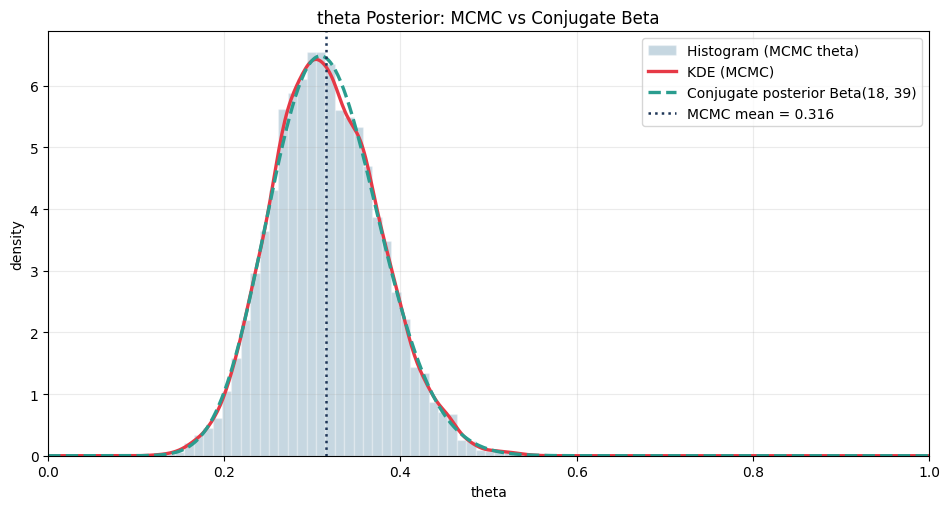

In [14]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Final overlay: MCMC histogram + KDE + conjugate posterior Beta(a0+y, b0+N-y)
theta_samples = theta_draws
kde = gaussian_kde(theta_samples)
x_grid = np.linspace(0, 1, 600)
conjugate_pdf = beta.pdf(x_grid, a_post, b_post)

plt.figure(figsize=(9.6, 5.2))
plt.hist(theta_samples, bins=40, density=True, alpha=0.30, color="#457B9D", edgecolor="white", label="Histogram (MCMC theta)")
plt.plot(x_grid, kde(x_grid), color="#E63946", linewidth=2.4, label="KDE (MCMC)")
plt.plot(x_grid, conjugate_pdf, color="#2A9D8F", linestyle="--", linewidth=2.4, label=f"Conjugate posterior Beta({a_post}, {b_post})")
plt.axvline(np.mean(theta_samples), color="#1D3557", linestyle=":", linewidth=1.8, label=f"MCMC mean = {np.mean(theta_samples):.3f}")

plt.title("theta Posterior: MCMC vs Conjugate Beta")
plt.xlabel("theta")
plt.ylabel("density")
plt.xlim(0, 1)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
# 96% credible intervals: conjugate symbolic posterior vs MCMC posterior
alpha_96 = 0.04
lower_q, upper_q = alpha_96 / 2, 1 - alpha_96 / 2  # 0.02, 0.98

# 1) Symbolic (conjugate) posterior: Beta(a0+y, b0+N-y)
ci96_symbolic = beta.ppf([lower_q, upper_q], a_post, b_post)

# 2) MCMC posterior from draws
ci96_mcmc = np.quantile(theta_draws, [lower_q, upper_q])

print("[96% Credible Interval]")
print(f"Symbolic conjugate Beta({a_post}, {b_post}): [{ci96_symbolic[0]:.6f}, {ci96_symbolic[1]:.6f}]")
print(f"MCMC (theta_draws quantiles 0.02, 0.98): [{ci96_mcmc[0]:.6f}, {ci96_mcmc[1]:.6f}]")

[96% Credible Interval]
Symbolic conjugate Beta(18, 39): [0.198141, 0.447268]
MCMC (theta_draws quantiles 0.02, 0.98): [0.199736, 0.448443]


End.